In [1]:
import matplotlib.pyplot as plt
import cv2
import os
import sys

proj_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if proj_path not in sys.path:
    sys.path.append(proj_path)


from IPython.display import Image
from convex_nmf import ConvexNMF
from standard_nmf import StandardNMF
from utils import compute_sparsity

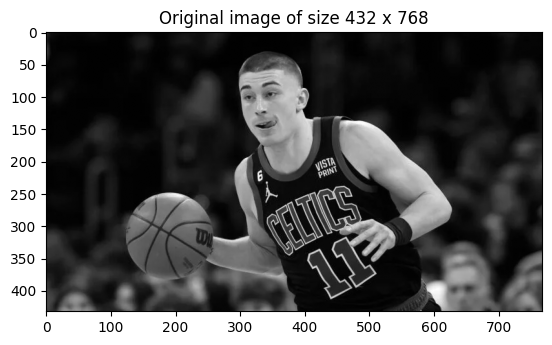

In [2]:
path = f'{proj_path}/data_files/prichard.png'
img = cv2.imread(path)
grayscale_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Noramlize image so NMF can be computed more easily
normalized_grayscale_img = grayscale_img / 255
m,n = normalized_grayscale_img.shape

plt.imshow(normalized_grayscale_img, cmap = 'gray')
plt.title(f'Original image of size {m} x {n}')
plt.show()

In [3]:
ranks = [5, 10, 15, 100]

### Rank 5 ###


  6%|▌         | 598/10000 [00:09<02:27, 63.94it/s]


Convergence achieved at iteration 598...
Proportion of non-zero elements for G_T and W: 0.5986979166666667, 0.22578125
### Rank 10 ###


  8%|▊         | 800/10000 [00:13<02:30, 61.13it/s]


Convergence achieved at iteration 800...
Proportion of non-zero elements for G_T and W: 0.44609375, 0.13854166666666667
### Rank 15 ###


 10%|▉         | 982/10000 [00:16<02:32, 59.25it/s]


Convergence achieved at iteration 982...
Proportion of non-zero elements for G_T and W: 0.36215277777777777, 0.10017361111111112
### Rank 100 ###


 20%|██        | 2029/10000 [00:47<03:04, 43.15it/s]


Convergence achieved at iteration 2029...
Proportion of non-zero elements for G_T and W: 0.133359375, 0.034440104166666666


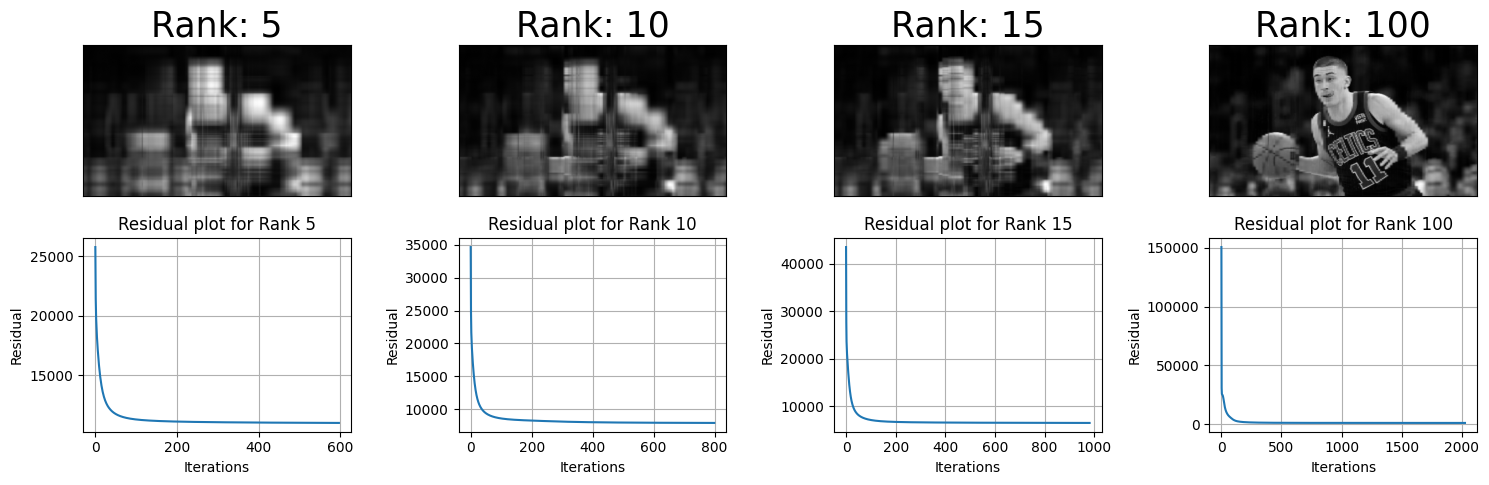

In [4]:
# Convex NMF
n_plots = len(ranks)
fig, ax = plt.subplots(2, n_plots, figsize=[15, 5])

n = 0
for rank in ranks:
    print(f'### Rank {rank} ###')
    CNMF = ConvexNMF(X = normalized_grayscale_img, r = rank, tol = 1e-5, max_iter = 10000, random_state=100, loss = "kl")
    F, W, G_T, residual_vector = CNMF.factorize()
    G_T_sparse, num_non_zero_G = compute_sparsity(G_T)
    W_sparse, num_non_zero_W = compute_sparsity(W)
    print(f'Proportion of non-zero elements for G_T and W: {num_non_zero_G}, {num_non_zero_W}')
    ax[0][n].imshow(F @ G_T, cmap='gray')
    ax[0][n].set_xticks([])
    ax[0][n].set_yticks([])
    ax[0][n].grid(True)
    ax[0][n].set_title('Rank: {}'.format(rank), fontsize=25)

    ax[1][n].plot(residual_vector)
    ax[1][n].set_xlabel('Iterations')
    ax[1][n].set_ylabel('Residual')
    ax[1][n].grid(True)
    ax[1][n].set_title(f'Residual plot for Rank {rank}')

    n += 1

plt.tight_layout()

## Rank: 5 ##


  1%|▏         | 142/10000 [00:00<00:11, 827.51it/s]


Convergence achieved at iteration 142...
Proportion of non-zero elements for W and H: 0.8203703703703704, 0.834375
## Rank: 10 ##


  5%|▍         | 480/10000 [00:00<00:11, 826.13it/s]


Convergence achieved at iteration 480...
Proportion of non-zero elements for W and H: 0.6006944444444444, 0.7040364583333333
## Rank: 15 ##


 10%|█         | 1001/10000 [00:01<00:09, 911.41it/s]


Convergence achieved at iteration 1001...
Proportion of non-zero elements for W and H: 0.5092592592592593, 0.6810763888888889
## Rank: 100 ##


 74%|███████▍  | 7396/10000 [00:16<00:05, 457.35it/s]


Convergence achieved at iteration 7396...
Proportion of non-zero elements for W and H: 0.2810648148148148, 0.6082161458333334


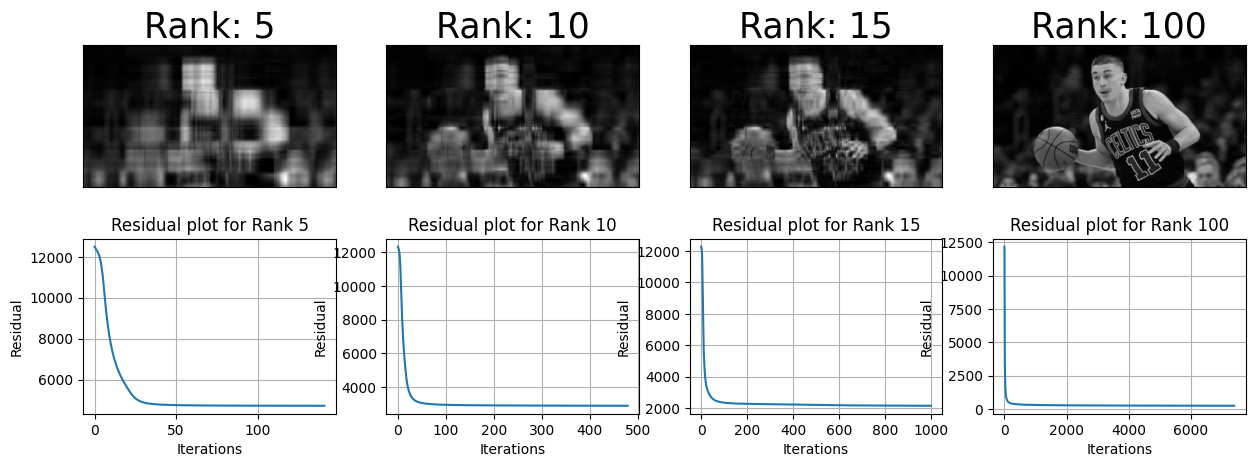

In [5]:
# Standard NMF
n_plots = len(ranks)
fig, ax = plt.subplots(2, n_plots, figsize=[15, 5])
n = 0
for rank in ranks:
    print(f'## Rank: {rank} ##')
    model = StandardNMF(normalized_grayscale_img, num_bases=rank, n_iter=10000, tol = 1e-5, random_state = 100)
    W, H, residual_vector = model.factorize()
    W_sparse, num_non_zero_W = compute_sparsity(W)
    H_sparse, num_non_zero_H = compute_sparsity(H)
    print(f'Proportion of non-zero elements for W and H: {num_non_zero_W}, {num_non_zero_H}')
    ax[0][n].imshow(W @ H, cmap='gray')
    ax[0][n].set_xticks([])
    ax[0][n].set_yticks([])
    ax[0][n].grid(True)
    ax[0][n].set_title('Rank: {}'.format(rank), fontsize=25)

    ax[1][n].plot(residual_vector)
    ax[1][n].set_xlabel('Iterations')
    ax[1][n].set_ylabel('Residual')
    ax[1][n].grid(True)
    ax[1][n].set_title(f'Residual plot for Rank {rank}')

    n += 1